In [1]:
import pandas as pd

In [3]:
path = "/content/online_retail.csv"

In [4]:
df = pd.read_csv(path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
df_cleaned = df.dropna(subset=['CustomerID'])
print("Shape of DataFrame after removing missing CustomerID values:", df_cleaned.shape)
df_cleaned.head()

Shape of DataFrame after removing missing CustomerID values: (406829, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]
df_cleaned = df_cleaned[df_cleaned['UnitPrice'] > 0]
print("Shape of DataFrame after removing non-positive Quantity and UnitPrice:", df_cleaned.shape)
df_cleaned.head()

Shape of DataFrame after removing non-positive Quantity and UnitPrice: (397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])
print(df_cleaned['InvoiceDate'].dtype)
df_cleaned.head()

datetime64[ns]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df_cleaned['PurchaseAmount'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']
print("DataFrame with 'PurchaseAmount' column added:")
df_cleaned.head()

DataFrame with 'PurchaseAmount' column added:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,PurchaseAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [13]:
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.DateOffset(days=1)
print(f"Snapshot Date for RFM analysis: {snapshot_date}")

Snapshot Date for RFM analysis: 2011-12-10 12:50:00


In [14]:
rfm_df = df_cleaned.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('PurchaseAmount', 'sum')
)

print("RFM DataFrame created:")
rfm_df.head()

RFM DataFrame created:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [15]:
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5, 4, 3, 2, 1])
print("RFM DataFrame with Recency scores added:")
rfm_df.head()

RFM DataFrame with Recency scores added:


,Recency,Frequency,Monetary,R_Score
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,5
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,4
12350.0,310,1,334.40,1


In [18]:
frequency_bins = pd.qcut(rfm_df['Frequency'], 5, duplicates='drop')
rfm_df['F_Score'] = frequency_bins.cat.codes + 1
print("RFM DataFrame with Frequency scores added:")
rfm_df.head()

RFM DataFrame with Frequency scores added (adjusted for unique bins):


,Recency,Frequency,Monetary,R_Score,F_Score
CustomerID,,,,,
12346.0,326,1,77183.60,1,1
12347.0,2,7,4310.00,5,4
12348.0,75,4,1797.24,2,3
12349.0,19,1,1757.55,4,1
12350.0,310,1,334.40,1,1


In [19]:
monetary_bins = pd.qcut(rfm_df['Monetary'], 5, duplicates='drop')
rfm_df['M_Score'] = monetary_bins.cat.codes + 1
print("RFM DataFrame with all R, F, and M scores added:")
rfm_df.head()

RFM DataFrame with all R, F, and M scores added:


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,4,5
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [20]:
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
print("RFM DataFrame with 'RFM_Segment' column added:")
rfm_df.head()

RFM DataFrame with 'RFM_Segment' column added:


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,4,5,545
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [21]:
import numpy as np

# Define RFM segments
conditions = [
    (rfm_df['R_Score'] >= 4) & (rfm_df['F_Score'] >= 4) & (rfm_df['M_Score'] >= 4), # Champions
    (rfm_df['R_Score'] >= 2) & (rfm_df['F_Score'] >= 3) & (rfm_df['M_Score'] >= 2), # Loyal Customers
    (rfm_df['R_Score'] >= 3) & (rfm_df['F_Score'] >= 1) & (rfm_df['M_Score'] >= 1), # Potential Loyalists
    (rfm_df['R_Score'] >= 4) & (rfm_df['F_Score'] == 1) & (rfm_df['M_Score'] == 1), # New Customers
    (rfm_df['R_Score'] >= 3) & (rfm_df['F_Score'] == 1) & (rfm_df['M_Score'] >= 1), # Promising
    (rfm_df['R_Score'] <= 2) & (rfm_df['F_Score'] <= 2) & (rfm_df['M_Score'] <= 2), # Lost Customers
    (rfm_df['R_Score'] <= 2) & (rfm_df['F_Score'] >= 2) & (rfm_df['M_Score'] >= 2), # At Risk Customers
    (rfm_df['R_Score'] <= 1) & (rfm_df['F_Score'] >= 3) & (rfm_df['M_Score'] >= 3), # Can't Lose Them
    (rfm_df['R_Score'] >= 2) & (rfm_df['F_Score'] <= 2) & (rfm_df['M_Score'] >= 2)  # Customers Needing Attention
]

choices = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'New Customers',
    'Promising',
    'Lost Customers',
    'At Risk Customers',
    'Can\'t Lose Them',
    'Customers Needing Attention'
]

rfm_df['RFM_Level'] = np.select(conditions, choices, default='Other')
print("RFM DataFrame with 'RFM_Level' column added:")
rfm_df.head()

RFM DataFrame with 'RFM_Level' column added:


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Level
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,Potential Loyalists
12347.0,2,7,4310.00,5,4,5,545,At Risk Customers
12348.0,75,4,1797.24,2,3,4,234,Loyal Customers
12349.0,19,1,1757.55,4,1,4,414,Other
12350.0,310,1,334.40,1,1,2,112,Potential Loyalists


In [22]:
print(rfm_df['RFM_Level'].value_counts())


RFM_Level
Potential Loyalists    2283
At Risk Customers      1018
Champions               306
Lost Customers          263
Other                   187
Loyal Customers         168
New Customers           113
Name: count, dtype: int64


### Marketing Strategies for RFM Segments

Based on the RFM segmentation, here are targeted marketing strategies for each identified customer group:

*   **Champions (R>=4, F>=4, M>=4)**:
    *   **Strategy**: Reward them for their loyalty, offer exclusive previews of new products, and encourage them to refer new customers. These are your best customers, so nurture them.
    *   **Actions**: Send personalized thank-you notes, offer VIP access to sales or events, provide early access to new collections, and implement a referral program with attractive incentives.

*   **Loyal Customers (R>=2, F>=3, M>=2)**:
    *   **Strategy**: Keep them engaged and satisfied. They are frequent buyers, but might not be your highest spenders or most recent purchasers. Focus on retention and increasing their purchase value.
    *   **Actions**: Implement loyalty programs with tiered rewards, send personalized product recommendations based on past purchases, offer bundles or discounts on complementary products, and provide excellent customer service.

*   **At Risk Customers (R<=2, F>=2, M>=2)**:
    *   **Strategy**: Re-engage them before they churn. These customers used to be frequent and valuable but haven't purchased recently. Understand why their activity has dropped.
    *   **Actions**: Send re-engagement campaigns with special discounts or personalized offers, highlight new or popular products they might like, send surveys to gather feedback on their inactivity, and offer incentives to make their next purchase.

*   **Potential Loyalists (R>=3, F>=1, M>=1)**:
    *   **Strategy**: Encourage them to become loyal customers. They have made a recent purchase and have some frequency/monetary value, but aren't yet highly engaged.
    *   **Actions**: Offer incentives for repeat purchases (e.g., "buy one get one X% off on your next purchase"), send personalized product suggestions based on their initial purchases, and provide useful content related to their interests.

*   **New Customers (R>=4, F=1, M=1)**:
    *   **Strategy**: Welcome them and provide a smooth onboarding experience to encourage their second purchase. They have purchased recently but only once and for a low monetary value.
    *   **Actions**: Send onboarding guides or welcome kits, offer a small welcome discount on their next purchase, provide excellent customer support for their initial queries, and send follow-up emails showcasing product benefits.

*   **Lost Customers (R<=2, F<=2, M<=2)**:
    *   **Strategy**: Attempt to win them back, or at least understand why they left. These customers have not purchased recently, frequently, or spent much.
    *   **Actions**: Implement win-back campaigns with significant incentives (e.g., deep discounts or exclusive offers), send surveys to understand reasons for churn, and if unsuccessful, remove them from active marketing lists to save resources.


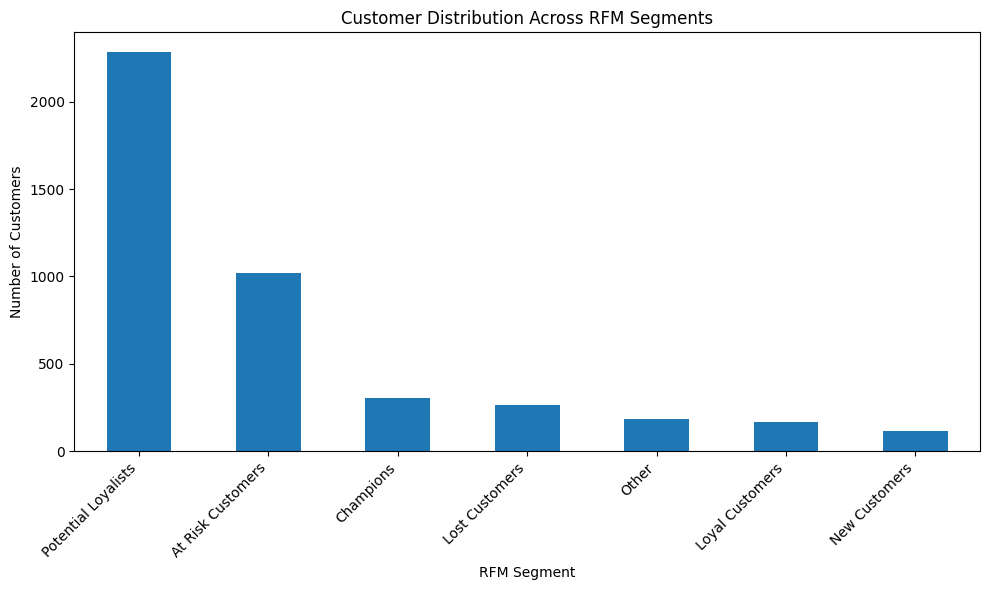

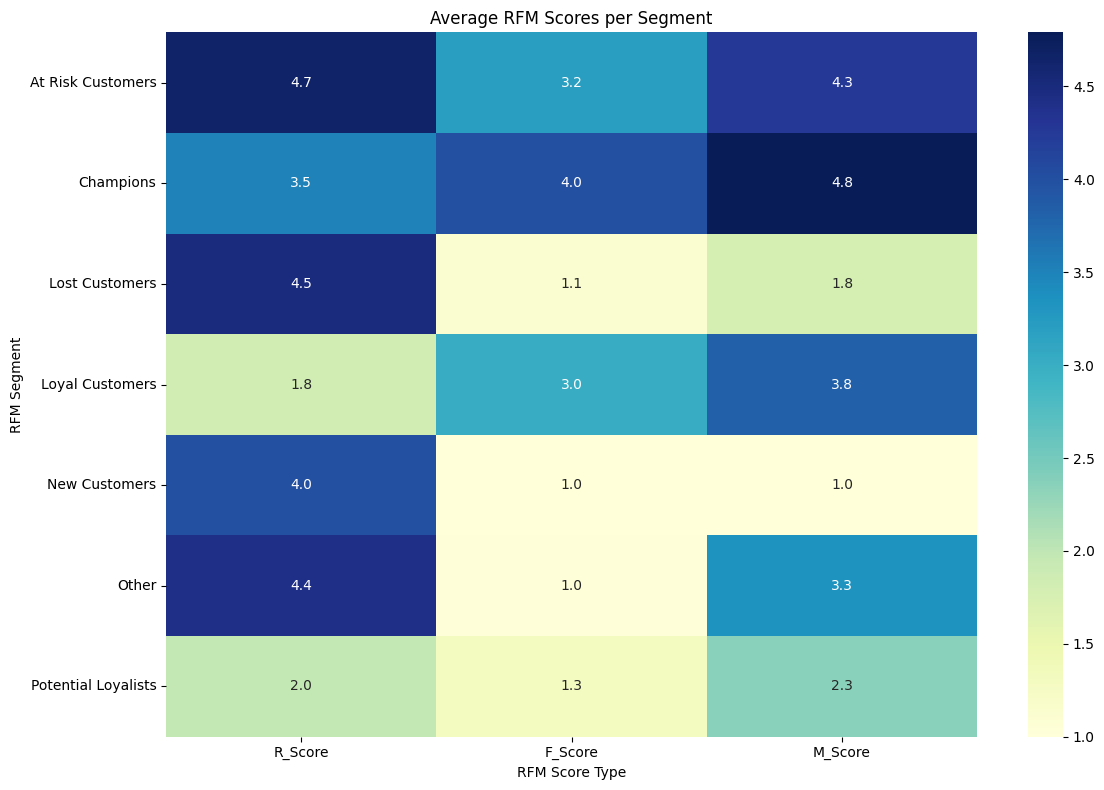

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of customers across RFM Levels
plt.figure(figsize=(10, 6))
rfm_df['RFM_Level'].value_counts().plot(kind='bar')
plt.title('Customer Distribution Across RFM Segments')
plt.xlabel('RFM Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Convert R_Score to integer to allow mean aggregation
rfm_df['R_Score'] = rfm_df['R_Score'].astype(int)

# Calculate mean RFM scores for each segment
rfm_agg = rfm_df.groupby('RFM_Level')[['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score']].mean()

# Create a heatmap of average RFM scores per segment
plt.figure(figsize=(12, 8))
sns.heatmap(rfm_agg[['R_Score', 'F_Score', 'M_Score']], annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Average RFM Scores per Segment')
plt.ylabel('RFM Segment')
plt.xlabel('RFM Score Type')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Data Preparation**:
    *   The initial dataset was cleaned by removing `397884` rows with missing `CustomerID` or non-positive `Quantity`/`UnitPrice`, ensuring valid transactions for analysis.
    *   A `PurchaseAmount` column was calculated by multiplying `Quantity` and `UnitPrice`.
    *   A `snapshot_date` of `2011-12-10 12:50:00` (one day after the latest transaction) was established as the reference point for Recency calculations.
*   **RFM Metrics Calculation**:
    *   Recency (days since last purchase), Frequency (number of unique purchases), and Monetary (total purchase amount) metrics were successfully calculated for each customer.
*   **RFM Score Assignment**:
    *   Customers were assigned R, F, and M scores from 1 to 5 based on their quantile distribution for each metric. Recency scores were inverted (5 for most recent, 1 for least recent).
    *   Challenges with duplicate values in `Frequency` and `Monetary` distributions were resolved by using `pd.qcut` with `duplicates='drop'` and converting categorical bins to 1-indexed numerical scores.
*   **Customer Segmentation**:
    *   Customers were grouped into distinct segments based on their RFM scores, creating an `RFM_Segment` (concatenation of scores) and a descriptive `RFM_Level`.
    *   The primary customer segments identified were:
        *   **Potential Loyalists**: 2283 customers, indicating a large group with some initial engagement.
        *   **At Risk Customers**: 1018 customers, suggesting a significant portion who are declining in activity.
        *   **Champions**: 306 customers, representing the most valuable and engaged customer group.
        *   **Lost Customers**: 263 customers, who have not purchased recently, frequently, or spent much.
        *   **New Customers**: 113 customers, who have made a recent but single low-value purchase.
        *   **Loyal Customers**: 168 customers.
*   **Marketing Strategy Suggestions**:
    *   Targeted marketing strategies were proposed for each segment, such as rewarding **Champions** with exclusive offers, re-engaging **At Risk Customers** with special discounts, and providing onboarding support for **New Customers**.
*   **Visualization**:
    *   A bar chart illustrated the distribution of customers across the identified RFM segments.
    *   A heatmap visualized the average R, F, and M scores for each segment, providing a clear overview of segment characteristics (e.g., Champions have high average R, F, and M scores, while Lost Customers have low scores).

### Insights

*   **Focus on 'Potential Loyalists' and 'At Risk Customers'**: Given that 'Potential Loyalists' (2283 customers) and 'At Risk Customers' (1018 customers) represent the largest segments outside of 'Other', marketing efforts should prioritize converting 'Potential Loyalists' into 'Loyal Customers' and re-engaging 'At Risk Customers' to prevent churn.
*   **Nurture 'Champions' and Analyze 'Lost Customers'**: Continue to reward 'Champions' (306 customers) to maintain their loyalty and advocacy. For 'Lost Customers' (263 customers), conduct further analysis to understand reasons for churn and evaluate the cost-effectiveness of win-back campaigns versus focusing on higher-potential segments.
